# ============================================
# CUSTOMER CHURN PREDICTION - END TO END
# ============================================

# 📦 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# --------------------------------------------
# 📂 2. LOAD DATASET
# --------------------------------------------
# Use Kaggle dataset: Churn_Modelling.csv
df = pd.read_csv("Churn_Modelling.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# Drop unnecessary columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# --------------------------------------------
# 🧹 3. DATA CLEANING & PREPROCESSING
# --------------------------------------------

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Encode categorical variables
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

# Feature Scaling
scaler = StandardScaler()

numerical_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# --------------------------------------------
# 📊 4. EXPLORATORY DATA ANALYSIS (EDA)
# --------------------------------------------

# Churn Distribution
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# --------------------------------------------
# 🧠 5. FEATURE ENGINEERING
# --------------------------------------------

# Balance per product
df["BalancePerProduct"] = df["Balance"] / (df["NumOfProducts"] + 1)

# Activity score
df["ActivityScore"] = df["IsActiveMember"] * df["Tenure"]

# --------------------------------------------
# 🎯 6. TRAIN-TEST SPLIT
# --------------------------------------------

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------
# 🤖 7. MODEL BUILDING
# --------------------------------------------

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --------------------------------------------
# 📈 8. MODEL EVALUATION
# --------------------------------------------

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

# --------------------------------------------
# 🔍 9. FEATURE IMPORTANCE (Random Forest)
# --------------------------------------------

importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:\n", feat_imp.head(10))

sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10))
plt.title("Top 10 Feature Importance")
plt.show()

# --------------------------------------------
# 🚨 10. HIGH-RISK CUSTOMER IDENTIFICATION
# --------------------------------------------

# Predict probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

high_risk_df = X_test.copy()
high_risk_df["Churn_Probability"] = y_prob

# High risk threshold
high_risk_customers = high_risk_df[high_risk_df["Churn_Probability"] > 0.7]

print("\nHigh Risk Customers:\n", high_risk_customers.head())

# Save for Power BI
high_risk_customers.to_csv("high_risk_customers.csv", index=False)

# --------------------------------------------
# 📊 11. EXPORT DATA FOR POWER BI
# --------------------------------------------

df.to_csv("cleaned_churn_data.csv", index=False)

# --------------------------------------------
# 💡 12. BUSINESS INSIGHT
# --------------------------------------------

print("\n🔎 BUSINESS INSIGHTS:")
print("""
Customers with:
- Low Balance
- Low Activity (IsActiveMember = 0)
- Higher Age

are more likely to churn.

Reason:
Inactive users with low engagement and low financial dependency 
on the bank are more likely to leave.

Action:
- Offer personalized offers
- Improve customer engagement
- Provide loyalty benefits
""")

# ============================================
# END OF PROJECT
# ============================================

Dataset Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826

c:\Users\Hari Priya\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


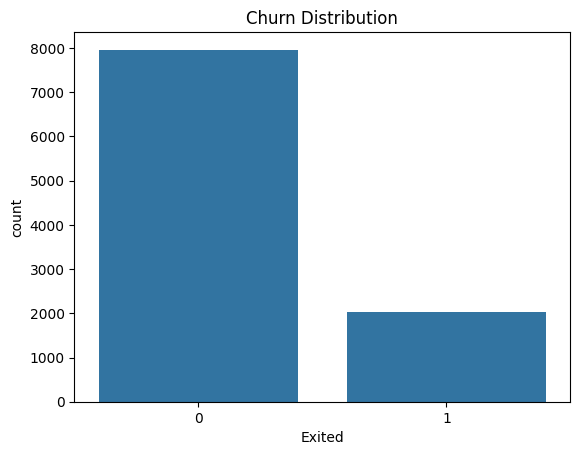

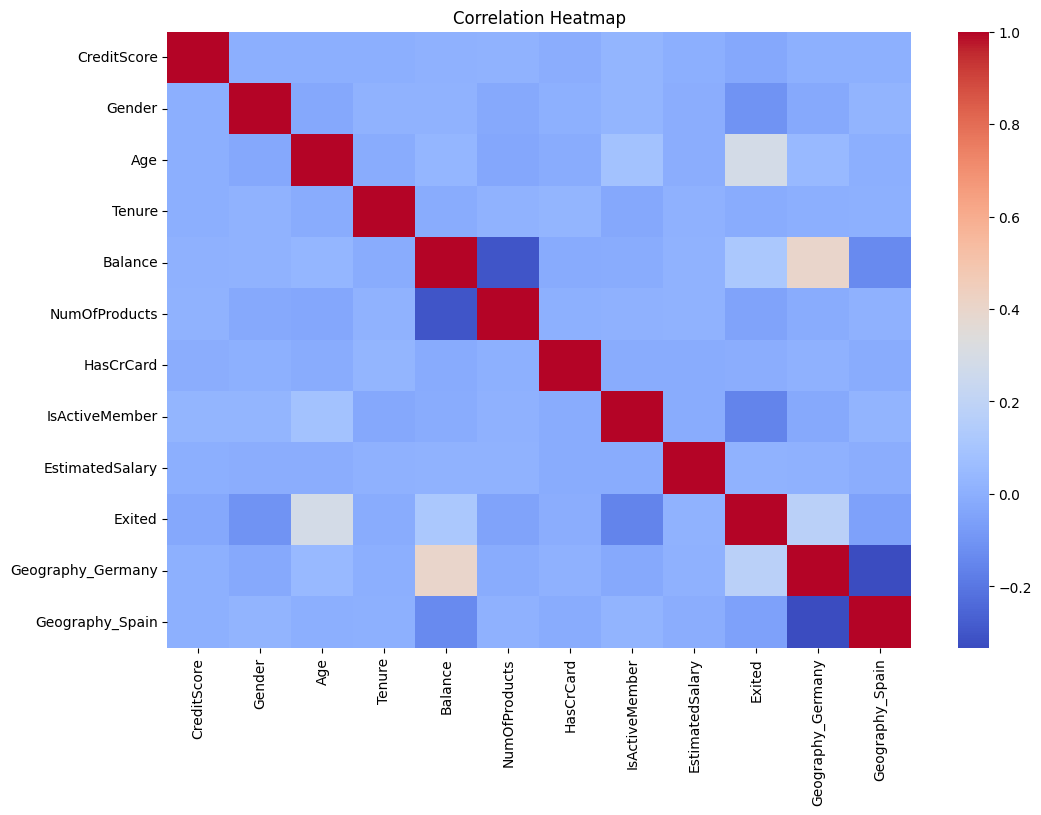


Logistic Regression Results:
Accuracy: 0.8185
ROC-AUC: 0.5977577424467699

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.96      0.89      1607
           1       0.60      0.23      0.34       393

    accuracy                           0.82      2000
   macro avg       0.72      0.60      0.62      2000
weighted avg       0.79      0.82      0.79      2000



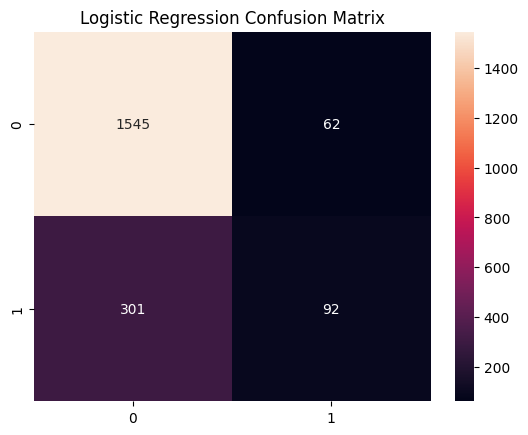


Random Forest Results:
Accuracy: 0.87
ROC-AUC: 0.7249564959916143

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.77      0.49      0.60       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



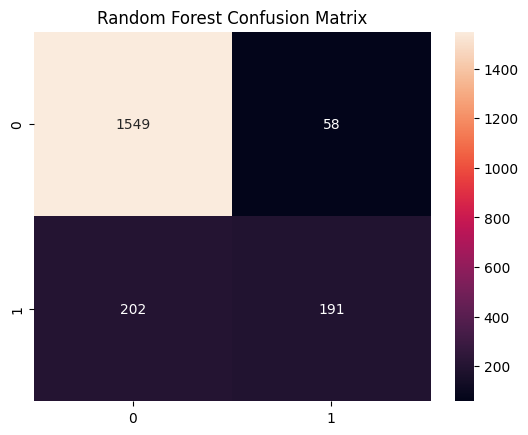


Top Features:
               Feature  Importance
2                 Age    0.224910
8     EstimatedSalary    0.123694
11  BalancePerProduct    0.119687
0         CreditScore    0.119111
5       NumOfProducts    0.114884
4             Balance    0.098127
3              Tenure    0.063351
12      ActivityScore    0.039138
9   Geography_Germany    0.024429
7      IsActiveMember    0.022505


c:\Users\Hari Priya\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


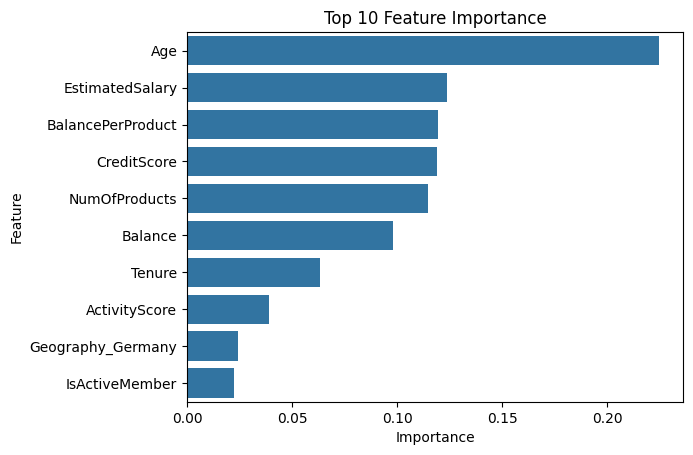


High Risk Customers:
       CreditScore  Gender       Age  Tenure   Balance  NumOfProducts  \
2750    -1.754076       0  1.723821       9 -1.225848              3   
7487     0.004875       0  1.628468       4 -1.225848              1   
5272     2.063884       1  0.770285       6 -1.225848              1   
3032    -1.609222       0  0.579578       3  0.203112              3   
764      0.615335       1  0.388871       2  1.019235              3   

      HasCrCard  IsActiveMember  EstimatedSalary  Geography_Germany  \
2750          1               1         1.210781              False   
7487          0               0        -0.273129              False   
5272          1               0         1.518073              False   
3032          1               0         0.609998              False   
764           1               1         1.005396               True   

      Geography_Spain  BalancePerProduct  ActivityScore  Churn_Probability  
2750            False          -0.306462

In [2]:
# ============================================
# CUSTOMER CHURN PREDICTION - END TO END
# ============================================

# 📦 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# --------------------------------------------
# 📂 2. LOAD DATASET
# --------------------------------------------
# Use Kaggle dataset: Churn_Modelling.csv
df = pd.read_csv(r"C:\Users\Hari Priya\Downloads\Churn_Modelling.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# Drop unnecessary columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# --------------------------------------------
# 🧹 3. DATA CLEANING & PREPROCESSING
# --------------------------------------------

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Encode categorical variables
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

# Feature Scaling
scaler = StandardScaler()

numerical_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# --------------------------------------------
# 📊 4. EXPLORATORY DATA ANALYSIS (EDA)
# --------------------------------------------

# Churn Distribution
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# --------------------------------------------
# 🧠 5. FEATURE ENGINEERING
# --------------------------------------------

# Balance per product
df["BalancePerProduct"] = df["Balance"] / (df["NumOfProducts"] + 1)

# Activity score
df["ActivityScore"] = df["IsActiveMember"] * df["Tenure"]

# --------------------------------------------
# 🎯 6. TRAIN-TEST SPLIT
# --------------------------------------------

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------
# 🤖 7. MODEL BUILDING
# --------------------------------------------

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --------------------------------------------
# 📈 8. MODEL EVALUATION
# --------------------------------------------

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

# --------------------------------------------
# 🔍 9. FEATURE IMPORTANCE (Random Forest)
# --------------------------------------------

importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:\n", feat_imp.head(10))

sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10))
plt.title("Top 10 Feature Importance")
plt.show()

# --------------------------------------------
# 🚨 10. HIGH-RISK CUSTOMER IDENTIFICATION
# --------------------------------------------

# Predict probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

high_risk_df = X_test.copy()
high_risk_df["Churn_Probability"] = y_prob

# High risk threshold
high_risk_customers = high_risk_df[high_risk_df["Churn_Probability"] > 0.7]

print("\nHigh Risk Customers:\n", high_risk_customers.head())

# Save for Power BI
high_risk_customers.to_csv("high_risk_customers.csv", index=False)

# --------------------------------------------
# 📊 11. EXPORT DATA FOR POWER BI
# --------------------------------------------

df.to_csv("cleaned_churn_data.csv", index=False)

# --------------------------------------------
# 💡 12. BUSINESS INSIGHT
# --------------------------------------------

print("\n🔎 BUSINESS INSIGHTS:")
print("""
Customers with:
- Low Balance
- Low Activity (IsActiveMember = 0)
- Higher Age

are more likely to churn.

Reason:
Inactive users with low engagement and low financial dependency 
on the bank are more likely to leave.

Action:
- Offer personalized offers
- Improve customer engagement
- Provide loyalty benefits
""")

# ============================================
# END OF PROJECT
# ============================================